## Comparative study of all the classification methods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score


In [2]:
df = pd.read_csv("bmw.csv")
df.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [3]:
median_price = df["price"].median()
df["price_class"] = (df["price"] > median_price).astype(int)


In [4]:
X = df.drop(["price", "price_class"], axis=1)
y = df["price_class"]


In [5]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns


In [10]:
preprocessor_dense = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", SVC())
    ]),

    "Naive Bayes": Pipeline([
        ("preprocessor", preprocessor_dense),
        ("model", GaussianNB())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ])
}


In [13]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy
0,Logistic Regression,0.908669
1,KNN,0.935559
2,SVM,0.478906
3,Naive Bayes,0.826611
4,Decision Tree,0.928141


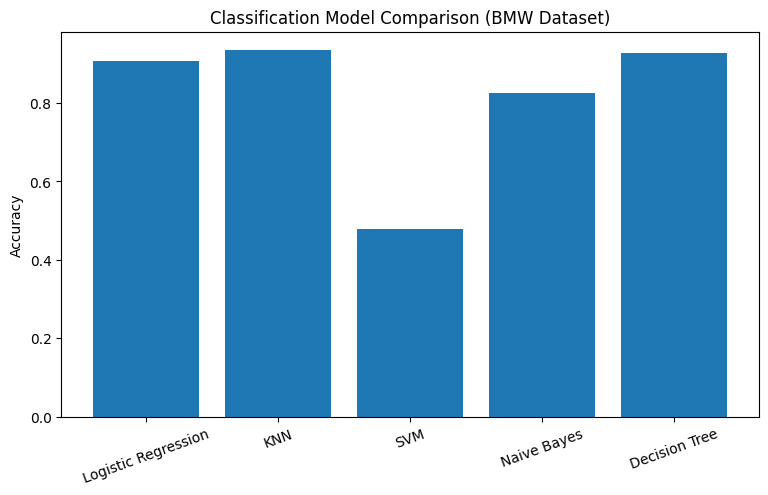

In [14]:
plt.figure(figsize=(9,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Classification Model Comparison (BMW Dataset)")
plt.xticks(rotation=20)
plt.show()
